## Bivariate Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

[*********************100%***********************]  1 of 1 completed


<Axes: >

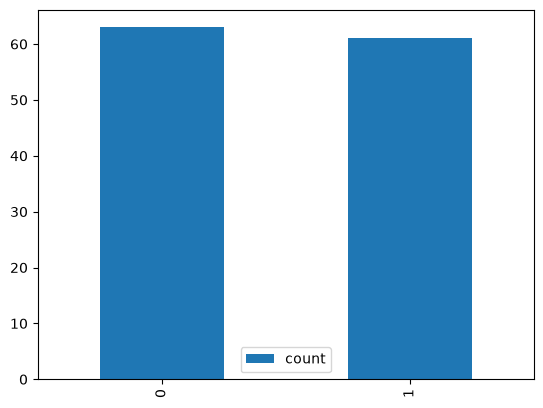

In [2]:
# Normal Frequency Table
data = yf.download(tickers='AAPL',start='2024-01-01',end='2024-06-30')
# right  do not have categorical data

# so categorical column data
data['Daily Returns']  = data['Close'].pct_change()
data['Categries of Daily Returns'] = data['Daily Returns'].apply(lambda x: "Positive" if x > 0 else "Negative")

# .value_counts() - Har value kitni baar aayi count karta hai:
freq = data['Categries of Daily Returns'].value_counts().reset_index()
freq.plot(kind='bar')


<Axes: >

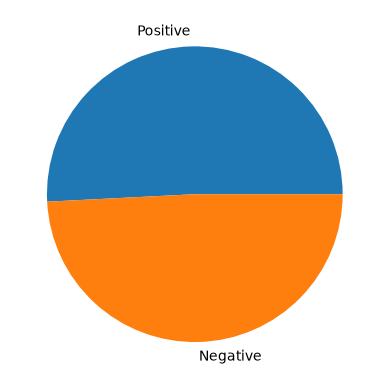

In [3]:
# Relative frequency - Relative Frequency = Frequency / Total observations
# Frequency (absolute count)	Positive = 63
# Relative Frequency	Positive = 63/124 = 0.508
# Percentage Frequency	Positive = 50.8%

# normalize=True - raw count nahi
# proportion (percentage ratio) do
# Positive = 63/124 = 0.508065
# Negative = 61/124 = 0.491935
# .reset_index() - Index ko normal column bana deta hai
# Positive → market 50.8% days upar gaya
# Negative → market 49.2% days niche gaya
# AI trading project mein iska use:

# Market bias detect karna
# Dataset balanced hai ya nahi dekhna
# ML classification se pehle target distribution check karna
# data['Categries of Daily Returns'].value_counts(normalize=True).reset_index()
# or
# data['Categries of Daily Returns'].value_counts(normalize=True).mul(100).round(2)
data['Categries of Daily Returns'].value_counts(normalize=True).plot(kind='pie')

In [ ]:
# Cumulative frequency
data['Categries of Daily Returns'].value_counts(normalize=True).reset_index().cumsum()

,Categries of Daily Returns,proportion
0,Positive,0.508065
1,PositiveNegative,1.000000


: 

<Axes: >

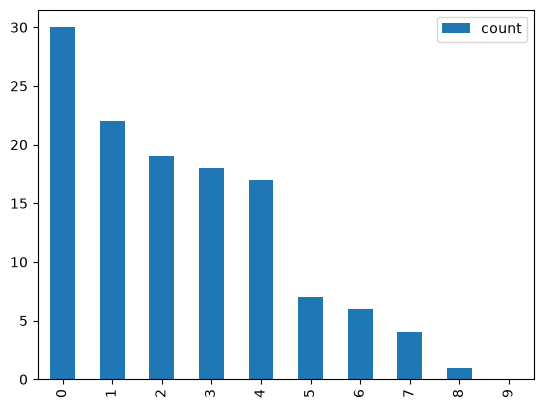

In [ ]:
# Numerical Column
# pd.cut(data['Close'],bins=10).value_counts().reset_index().plot(kind='bar')
# data
# data['Close']
# pd.cut(data['Close'],bins=10)
# pd.cut() - Ye continuous values ko groups / intervals (bins) mein divide karta hai.
# Suppose prices:

# 100
# 120
# 145
# 180
# 200
# 220
# 250

# Aur:

# pd.cut(price,bins=3)

# Internally:

# (99,150]
# (150,200]
# (200,250]

# Output:

# 100 → (99,150]
# 120 → (99,150]
# 145 → (99,150]
# 180 → (150,200]
# 220 → (200,250]

# Use case in AI trading:

# Stock prices ko ranges mein convert karna
# Feature engineering
# Risk categories banana
# ML mein bahut use hota hai jab continuous values ko categories mein convert karna hota ha
pd.cut(data[('Close','AAPL')], bins=10).value_counts().reset_index().plot(kind='bar')  #- it will draw bar chart


(array([22., 18.,  4., 30., 19., 17.,  1.,  0.,  6.,  7.]),
 array([163.36140442, 168.50618439, 173.65096436, 178.79574432,
        183.94052429, 189.08530426, 194.23008423, 199.3748642 ,
        204.51964417, 209.66442413, 214.8092041 ]),
 <BarContainer object of 10 artists>)

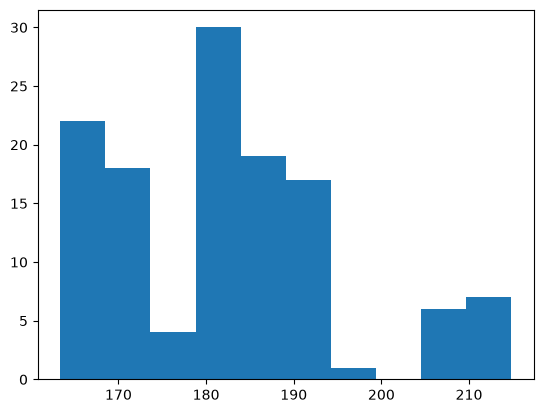

In [ ]:
# historgram 
# if more bins provided - then it will not give good result - balanced bins must be provided
plt.hist(data[('Close','AAPL')], bins=10)

In [ ]:
# in bivariate analysis
# Categorical - Categorical
# Categorical - Numerical
# Numerical - Numerical

In [21]:
# create another categorical column
data['Day name'] = data.index.day_name()

In [22]:
data

Price,Close,High,Low,Open,Volume,Daily Returns,Categries of Daily Returns,Day name
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,
Date,,,,,,,,
2024-01-02,183.562164,186.330827,181.831752,185.055258,82488700,NaN,Negative,Tuesday
2024-01-03,182.187729,183.799489,181.376900,182.158066,58414500,-0.007488,Negative,Wednesday
2024-01-04,179.873917,181.040702,178.855446,180.111221,71983600,-0.012700,Negative,Thursday
2024-01-05,179.152115,180.714432,178.153425,179.953062,62379700,-0.004013,Negative,Friday
2024-01-08,183.483078,183.522639,179.468523,180.051916,59144500,0.024175,Positive,Monday
...,...,...,...,...,...,...,...,...
2024-06-24,206.352478,210.873314,204.815787,205.936087,80727000,0.003133,Positive,Monday
2024-06-25,207.274506,209.564665,206.818449,207.353805,55549700,0.004468,Positive,Tuesday


In [24]:
data['Categries of Daily Returns']

Date
2024-01-02    Negative
2024-01-03    Negative
2024-01-04    Negative
2024-01-05    Negative
2024-01-08    Positive
                ...   
2024-06-24    Positive
2024-06-25    Positive
2024-06-26    Positive
2024-06-27    Positive
2024-06-28    Negative
Name: Categries of Daily Returns, Length: 124, dtype: str

In [ ]:
# create contigency table
#  by this we can analyse on which days getting positve return on which day getting negavtive return
pd.crosstab(data['Categries of Daily Returns'],data['Day name'])

Day name,Friday,Monday,Thursday,Tuesday,Wednesday
Categries of Daily Returns,,,,,
Negative,13,10,14,12,12
Positive,12,12,12,14,13


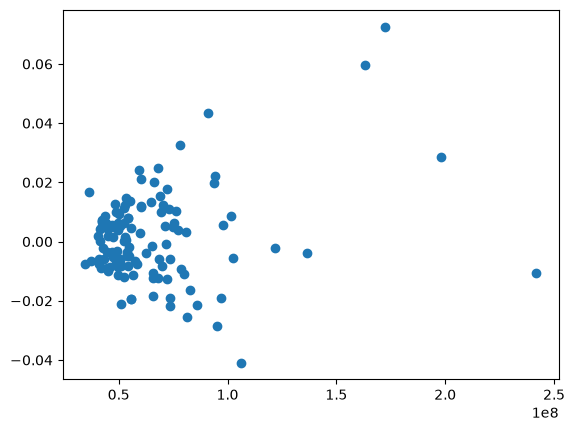

In [ ]:
# on 2 numerical columns - draw scatter plot
# Numerical - Numerical
plt.scatter(data['Volume'],data['Daily Returns'])

<Axes: title={'center': 'Daily Returns'}, xlabel='Categries of Daily Returns'>

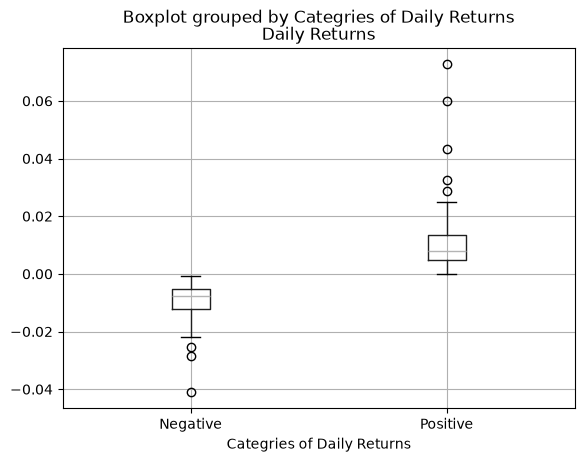

In [ ]:
# box plot
# Categorical - Numerical
# box plot apply on data frame
# boxplot -Yeh individual points nahi, distribution ka summary dikhata hai.
# Interpretation:

# Positive days stable hain

# Negative days zyada volatile hain

# AI trading mein use:

# Market volatility dekhna
# Extreme movements detect karna
# Outliers remove karna
# ML model se pehle data understand karna

# Ek simple memory trick:

# Median → center
# Box → middle 50%
# Whiskers → normal range
# Dots → unusual values

# Yehi boxplot ka main meaning hai.
data.boxplot(column='Daily Returns',by='Categries of Daily Returns')